In [ ]:
import os, sys

sys.path.append(os.path.abspath(os.path.join(os.path.dirname("utils"), "..")))
from module.utils import *
from module.prompt import *
from module.custom_model import *
from module.base_model import *
from module.tools import *

In [ ]:
start_langsmith("test_python")

LangSmith 추적을 시작합니다.
[프로젝트명]
test_python


In [ ]:
import os, sys

sys.path.append(os.path.abspath(os.path.join(os.path.dirname("utils"), "..")))
from module.state import *
from module.prompt import *
from module.custom_model import *
from module.base_model import *
from module.tools import *
from module.db_query import *


def get_prompt_data_analysis():
    template = """ 
    You are an AI assistant
    It analyzes the user's questions and answers and previous conversation records to analyze, compare, and visualize data. 

    # User Request : 
    {current_steps}

    # Summary of conversation earlier: : 
    {summary}
    
    # placeholder:
    {messages}

    # Important :
    If there is no special request from the user, please make your own judgment and select the chart. 
    Make sure to answer in English when writing the code because errors may occur when writing in Korean.

    """
    return ChatPromptTemplate.from_template(template)


def get_prompt_answer():
    prompt = """ 
    You are a data analysis expert
    Print your final answer based on the python code you ran previously



    # User Request : 
    {current_steps}
    
    # Summary of conversation earlier :
    {summary}

    # placeholder:
    {messages}

    # important: 
    you must always answer in Korean.
    """
    return ChatPromptTemplate.from_template(prompt)


def get_python_tool():
    """
    create python code
    """
    return PythonAstREPLTool()


def instruction_node(state: DataState):
    plan = state.get("plan", [state["question"]])
    text_plan = "\n".join(f"{idx+1}. {text}" for idx, text in enumerate(plan))
    task = plan[0]
    task_str = f"""For the following plan: \n\n {text_plan} \n\n You are tasked with executing [step 1. {task}]."""
    return DataState({"messages": task_str, "current_steps": task_str, "plan": plan})


def data_analysis_node(state: DataState):
    messages = state.get("messages", "")
    current_steps = state["current_steps"]
    summary = state.get("summary", "")
    python_tool = get_python_tool()
    tools = [python_tool]  # 필요 시 여러 도구 추가
    llm = get_gpt().bind_tools(tools, tool_choice="python_repl_ast")
    chain = get_prompt_data_analysis() | llm

    result = chain.invoke(
        {"current_steps": current_steps, "messages": messages, "summary": summary}
    )
    code = result.tool_calls[0]["args"]["query"]
    return DataState({"messages": code, "code": code})


def answer_node(state: DataState):
    prompt = get_prompt_answer()
    llm = get_gpt()
    query_gen_llm = prompt | llm
    summary = state.get("summary", "")
    current_steps = state["current_steps"]
    messages = state["messages"]
    result = query_gen_llm.invoke(
        {"summary": summary, "current_steps": current_steps, "messages": messages}
    )
    latest_messages = f" This step is done : {result.content}"
    code = state["code"]
    exec(code)
    return DataState(
        {
            "past_steps": result,
            "messages": latest_messages,
            "answer": latest_messages,
        }
    )


def replan_node(state: SubState):
    plan = state["plan"]
    current_steps = state["current_steps"]
    past_steps = state["past_steps"]
    # plan과 current, done 비교하여 plan 제거


def next_step_agent(state: SubState):
    # 다음 plan가져와서 사용할 agent 선택
    # 만약 다음 plan 없는 경우 일상 대화 선택
    return


def final_node(state: SubState):
    # answer_node 의 answer 와
    # 다음 plan
    # next_step_agent
    # 사용 여부 확인
    return


def get_data_analsys_graph():
    sub_state_graph = StateGraph(DataState)
    sub_state_graph.add_node("instruction_node", instruction_node)
    sub_state_graph.add_node("data_analysis_node", data_analysis_node)
    sub_state_graph.add_node("answer_node", answer_node)

    sub_state_graph.add_edge(START, "instruction_node")
    sub_state_graph.add_edge("instruction_node", "data_analysis_node")
    sub_state_graph.add_edge("data_analysis_node", "answer_node")
    sub_state_graph.add_edge("answer_node", END)

    sub_ck = get_check_pointer()
    sub_graph = sub_state_graph.compile(checkpointer=sub_ck)
    return sub_graph


graph = get_data_analsys_graph()

In [ ]:
inputs = {
    "question": "주어진 정보를 시각화해줘 ",
    "messages": [
        HumanMessage(
            content="For the following plan: \n\n 1. 안녕 난 Kara Nielsen 이야 내 favoritemusic 조회해줘  \n\n You are tasked with executing [step 1. 안녕 난 Kara Nielsen 이야 내 favoritemusic 조회해줘 ].",
            additional_kwargs={},
            response_metadata={},
            id="92197265-6b8d-4394-bcf7-539c9b3eca4a",
        ),
        AIMessage(
            content="",
            additional_kwargs={
                "tool_calls": [
                    {
                        "index": 0,
                        "id": "call_UpW8zr69U0nZqtDKXm1oFkbb",
                        "function": {"arguments": "{}", "name": "sql_db_list_tables"},
                        "type": "function",
                    }
                ]
            },
            response_metadata={
                "finish_reason": "stop",
                "model_name": "gpt-4.1-mini-2025-04-14",
                "system_fingerprint": "fp_c064fdde7c",
                "service_tier": "default",
            },
            id="run--8de1e886-186d-4b6a-b0ec-63e1f18e5b44",
            tool_calls=[
                {
                    "name": "sql_db_list_tables",
                    "args": {},
                    "id": "call_UpW8zr69U0nZqtDKXm1oFkbb",
                    "type": "tool_call",
                }
            ],
        ),
        ToolMessage(
            content="Album, Artist, Customer, Employee, FavoriteMusic, Genre, Invoice, InvoiceLine, MediaType, Playlist, PlaylistTrack, Track",
            name="sql_db_list_tables",
            id="a608c2d8-12b5-46ca-8407-c88d19399758",
            tool_call_id="call_UpW8zr69U0nZqtDKXm1oFkbb",
        ),
        AIMessage(
            content="",
            additional_kwargs={
                "tool_calls": [
                    {
                        "index": 0,
                        "id": "call_2khObEGZ7InQacSCktpWAZeQ",
                        "function": {
                            "arguments": '{"table_names":"FavoriteMusic"}',
                            "name": "sql_db_schema",
                        },
                        "type": "function",
                    }
                ]
            },
            response_metadata={
                "finish_reason": "stop",
                "model_name": "gpt-4.1-mini-2025-04-14",
                "system_fingerprint": "fp_c064fdde7c",
                "service_tier": "default",
            },
            id="run--57f3b347-6d36-4ae8-8d06-cf6d3cb1193d",
            tool_calls=[
                {
                    "name": "sql_db_schema",
                    "args": {"table_names": "FavoriteMusic"},
                    "id": "call_2khObEGZ7InQacSCktpWAZeQ",
                    "type": "tool_call",
                }
            ],
        ),
        ToolMessage(
            content='\nCREATE TABLE "FavoriteMusic" (\n\t"FavoriteMusicId" INTEGER, \n\t"CustomerId" INTEGER NOT NULL, \n\t"TrackId" INTEGER NOT NULL, \n\tPRIMARY KEY ("FavoriteMusicId"), \n\tFOREIGN KEY("CustomerId") REFERENCES "Customer" ("CustomerId"), \n\tFOREIGN KEY("TrackId") REFERENCES "Track" ("TrackId")\n)\n\n/*\n3 rows from FavoriteMusic table:\nFavoriteMusicId\tCustomerId\tTrackId\n1\t9\t3256\n2\t9\t3268\n3\t9\t325\n*/',
            name="sql_db_schema",
            id="1c4e4ed5-6365-4360-87ee-e0c4cb73b9d6",
            tool_call_id="call_2khObEGZ7InQacSCktpWAZeQ",
        ),
        AIMessage(
            content="SELECT fm.FavoriteMusicId, t.Name AS TrackName, a.Name AS ArtistName\nFROM FavoriteMusic fm\nJOIN Customer c ON fm.CustomerId = c.CustomerId\nJOIN Track t ON fm.TrackId = t.TrackId\nJOIN Album al ON t.AlbumId = al.AlbumId\nJOIN Artist a ON al.ArtistId = a.ArtistId\nWHERE c.FirstName = 'Kara' AND c.LastName = 'Nielsen';",
            additional_kwargs={},
            response_metadata={
                "finish_reason": "stop",
                "model_name": "gpt-4.1-mini-2025-04-14",
                "system_fingerprint": "fp_c064fdde7c",
                "service_tier": "default",
            },
            id="run--de20fedc-a130-44e9-b5d2-71d547384264",
        ),
        HumanMessage(
            content="yes",
            additional_kwargs={},
            response_metadata={},
            id="12b7315a-0361-44fe-8772-bc510dcbf6db",
        ),
        AIMessage(
            content="Success: [(1, 'Give Peace a Chance', 'U2'), (2, 'Beautiful Boy', 'U2'), (3, 'TriboTchan', 'Various Artists'), (4, 'Tapa Aqui, Descobre Ali', 'Various Artists'), (5, 'Levada do Amor (Ailoviu)', 'Various Artists')]",
            additional_kwargs={},
            response_metadata={},
            id="2d7df429-7013-4e71-b8ed-db035b2185c6",
        ),
        HumanMessage(
            content=' This step is done : Kara Nielsen님의 즐겨찾기 음악 목록은 다음과 같습니다:\n\n1. "Give Peace a Chance" - 아티스트: U2  \n2. "Beautiful Boy" - 아티스트: U2  \n3. "TriboTchan" - 아티스트: Various Artists  \n4. "Tapa Aqui, Descobre Ali" - 아티스트: Various Artists  \n5. "Levada do Amor (Ailoviu)" - 아티스트: Various Artists  \n\n이 곡들은 Kara Nielsen 고객님의 FavoriteMusic 테이블에 등록된 즐겨찾기 트랙들입니다.',
            additional_kwargs={},
            response_metadata={},
            id="73a2a4b3-be7f-45f1-adbe-0620e949e001",
        ),
    ],
    "current_steps": "For the following plan: \n\n 1. 안녕 난 Kara Nielsen 이야 내 favoritemusic 조회해줘  \n\n You are tasked with executing [step 1. 안녕 난 Kara Nielsen 이야 내 favoritemusic 조회해줘 ].",
    "past_steps": [
        AIMessage(
            content='Kara Nielsen님의 즐겨찾기 음악 목록은 다음과 같습니다:\n\n1. "Give Peace a Chance" - 아티스트: U2  \n2. "Beautiful Boy" - 아티스트: U2  \n3. "TriboTchan" - 아티스트: Various Artists  \n4. "Tapa Aqui, Descobre Ali" - 아티스트: Various Artists  \n5. "Levada do Amor (Ailoviu)" - 아티스트: Various Artists  \n\n이 곡들은 Kara Nielsen 고객님의 FavoriteMusic 테이블에 등록된 즐겨찾기 트랙들입니다.',
            additional_kwargs={},
            response_metadata={
                "finish_reason": "stop",
                "model_name": "gpt-4.1-mini-2025-04-14",
                "system_fingerprint": "fp_c064fdde7c",
                "service_tier": "default",
            },
            id="run--b0a675da-0f1a-4867-9bb6-2752597852a2",
        )
    ],
    "answer": ' This step is done : Kara Nielsen님의 즐겨찾기 음악 목록은 다음과 같습니다:\n\n1. "Give Peace a Chance" - 아티스트: U2  \n2. "Beautiful Boy" - 아티스트: U2  \n3. "TriboTchan" - 아티스트: Various Artists  \n4. "Tapa Aqui, Descobre Ali" - 아티스트: Various Artists  \n5. "Levada do Amor (Ailoviu)" - 아티스트: Various Artists  \n\n이 곡들은 Kara Nielsen 고객님의 FavoriteMusic 테이블에 등록된 즐겨찾기 트랙들입니다.',
    "db_query": "SELECT fm.FavoriteMusicId, t.Name AS TrackName, a.Name AS ArtistName\nFROM FavoriteMusic fm\nJOIN Customer c ON fm.CustomerId = c.CustomerId\nJOIN Track t ON fm.TrackId = t.TrackId\nJOIN Album al ON t.AlbumId = al.AlbumId\nJOIN Artist a ON al.ArtistId = a.ArtistId\nWHERE c.FirstName = 'Kara' AND c.LastName = 'Nielsen';",
}


🔄 Node: data_analysis_node 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 

🔄 Node: answer_node 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
Kara Nielsen님의 즐겨찾기 음악 아티스트별 트랙 수를 시각화한 결과는 다음과 같습니다:

- U2: 2곡  
- Various Artists: 3곡

이를 막대그래프로 표현하면, Various Artists가 3곡으로 가장 많고, U2가 2곡으로 뒤를 잇는 것을 확인할 수 있습니다.

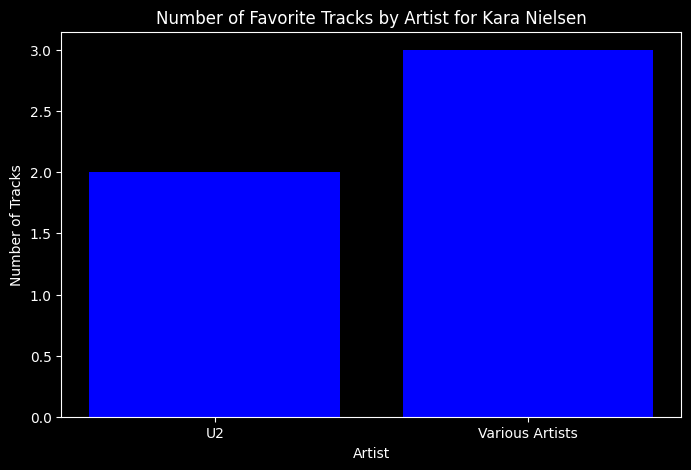

In [21]:
config = get_runnable_config(recursion_limit=20, thread_id=get_random_uuid())
# messages  = "favorite music table 아무정보없어?"
# inputs = {"question": "봄 평균온도 29, 여름 평균온도 30 막대그래프 그려줘"}
stream_graph(
    graph=graph,
    config=config,
    inputs=inputs,
)

In [15]:
snapshot = graph.get_state(config)
snapshot.values

{'question': '안녕 난 Kara Nielsen 이야 내 favoritemusic 조회해줘 ',
 'messages': [HumanMessage(content='For the following plan: \n\n 1. 안녕 난 Kara Nielsen 이야 내 favoritemusic 조회해줘  \n\n You are tasked with executing [step 1. 안녕 난 Kara Nielsen 이야 내 favoritemusic 조회해줘 ].', additional_kwargs={}, response_metadata={}, id='27f8d74a-46c6-4430-ac63-13300e29ba56'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'index': 0, 'id': 'call_TdaMFP1gwtLf8Qk4kepuCIRZ', 'function': {'arguments': '{}', 'name': 'sql_db_list_tables'}, 'type': 'function'}]}, response_metadata={'finish_reason': 'stop', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_c064fdde7c', 'service_tier': 'default'}, id='run--5902222d-aa19-4937-b5b6-f13c920a6902', tool_calls=[{'name': 'sql_db_list_tables', 'args': {}, 'id': 'call_TdaMFP1gwtLf8Qk4kepuCIRZ', 'type': 'tool_call'}]),
  ToolMessage(content='Album, Artist, Customer, Employee, FavoriteMusic, Genre, Invoice, InvoiceLine, MediaType, Playlist, PlaylistTrack,